In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Understanding the Variables (6 marks)

-Identify and clearly describe each column in the EV Market & Orders dataset.                                                                         
-Classify the variables into numerical, categorical, ordinal, or datetime types.

-Discuss potential relationships between key variables
(e.g., battery capacity vs. driving range, vehicle price vs. order quantity, discounts vs.
total order value).


In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv(r"/content/drive/MyDrive/Data Science Project/Dataset.csv") # if the columns do not have column names "header=None" makes it so that the first row will not be the first row and replaced with the index

df.head()

In [ ]:
print(df.info())
print(df.describe(include='all'))

In [ ]:
display(df.head(10))

In [ ]:

obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.lower()

print("Cleaned DataFrame:")
df.head()

# 2. Data Cleaning

**Handling Missing Values**

In [ ]:
df.isnull().sum()
# check the sum of and null data

*Customer Segment*

In [ ]:
df['customer_segment'].unique()
df['customer_segment'].value_counts()

In [ ]:
df["customer_segment"] = df["customer_segment"].fillna("personal")
df.isnull().sum()

*Region*

In [ ]:
df['region'].unique()
df['region'].value_counts()

In [ ]:
df["region"] = df["region"].fillna("south")
df.head(20)

In [ ]:
df.isnull().sum()

*Country & City*

In [ ]:
df['country'].unique()
df['country'].value_counts()

In [ ]:
df['city'].unique()
df['city'].value_counts()

In [ ]:
city_to_country = {'singapore':'singapore',
'penang':'malaysia',
'chiang mai':'thailand',
'johor bahru':'malaysia',
'kuala lumpur':'malaysia',
'bangkok':'thailand',
'shah alam':'malaysia',
'surabaya':'indonesia',
'jakarta':'indonesia',
'ho chi minh city':'vietnam',
'hanoi':'vietnam'}

df["country"] = df["country"].fillna(df["city"].map(city_to_country))

df.head()


In [ ]:
df.isnull().sum()

for country_to_city, I just take the most used city through .value_counts() and put the mode city for the country.

In [ ]:
country_to_city = {'singapore':'singapore',
'malaysia':'kuala lumpur',
'thailand':'bangkok',
'indonesia':'jakarta',
'vietnam':'ho chi minh city'}

df["city"] = df["city"].fillna(df["country"].map(country_to_city))

df.head(5)

In [ ]:
df.isnull().sum()

*Check if there is a row with no city and country.*

In [ ]:
# there is one row with no city and country data in it so lets see what it is

df[df['city'].isna() & df['country'].isna()]


In [ ]:
# lets jut put the average country to city just incase since its just only one row
#                                                     *here put colum name*
df.loc[(df["order_id"] == 500180) & (df["country"].isna()),"country"] = "malaysia"
df.loc[(df["order_id"] == 500180) & (df["city"].isna()),"city"] = "kuala lumpur"

df.loc[(df["order_id"] == 500180)]



In [ ]:
df.isnull().sum()

*battery_capacity_kwh*


*We can se some variables have 'kwh' in them*

In [ ]:
# turn to string for better filtering then turn it into int later

df.head(10)

In [ ]:
df['battery_capacity_kwh'] = df['battery_capacity_kwh'].str.replace("kwh", "", regex=True)

*Checks if the 'kwh' letter is there*

In [ ]:

df[df['battery_capacity_kwh'].str.contains('kwh', na=False)]

*make battery_capacity_kwh into a flat*

In [ ]:
df['battery_capacity_kwh'] = df['battery_capacity_kwh'].astype('float')

*Find the mean to impute into empty battery_capacity_kwh*

In [ ]:
mean_normal = df['battery_capacity_kwh'].mean()

mean_normal = round(mean_normal, 0)

print("the Mean value for battery capacity kwh is:",mean_normal)

In [ ]:
df['battery_capacity_kwh'].replace(np.nan, 75.0, inplace=True)

df.head(5)


In [ ]:
df.isnull().sum()

*range_km*

*We see that there is a outlier data in this which is 3000.0*

In [ ]:
min_range= df['range_km'].min()
max_range = df['range_km'].max()

print(min_range)
print(max_range)

*check the range_km where is there are rows larger than 1000 on the range_km*

In [ ]:
df.loc[(df["range_km"] >= 1000)]

In [ ]:
df.loc[(df["range_km"] == 3000)]

In [ ]:
(df["range_km"] == 3000).sum()


*Check the mean with and without the '3000' range_km.*

In [ ]:
range_km_mean_without_3000 = df.loc[df['range_km'] != 3000, 'range_km'].mean()
range_km_mean_with_3000 = df['range_km'].mean()

print("With outliers Removed:",round(range_km_mean_without_3000, 0))
print("With outliers Included:", round(range_km_mean_with_3000, 0))

impute 449.0 into the empty range_km

In [ ]:
df['range_km'].replace(np.nan, 449.0, inplace=True)

df[['order_id','range_km']].head(22)

In [ ]:
df.isnull().sum()

*Charging_type*

In [ ]:
print(df['charging_type'].unique())
df['charging_type'].value_counts()

In [ ]:
df['charging_type'].replace(np.nan, "ac", inplace=True)

df.loc[df['order_id'] == 500140, ['order_id','charging_type']] # in the raw and initial previous dataset, 'order_id' 500140' was a nan NaN.

In [ ]:
df.isnull().sum()

*base_price_usd.*

In [ ]:
print(df.info())

In [ ]:
df['base_price_usd'] = df['base_price_usd'].str.replace(",", "", regex=True)

df['base_price_usd'] = df['base_price_usd'].astype('float')

df.loc[df['order_id'] == 500044, ['order_id','base_price_usd']]

In [ ]:
max = df['base_price_usd'].max()
min = df['base_price_usd'].min()
mean = df['base_price_usd'].mean()

print(round(max,0))
print(round(min,0))
print(round(mean,0))

In [ ]:
df['base_price_usd'].replace(np.nan, 43082.0, inplace=True)

In [ ]:
df.loc[df['order_id'] == 500022, ['order_id','base_price_usd']]

In [ ]:
df.isnull().sum()

*final_price*

In [ ]:
print(df.info())

*The final_price_usd has a bunch of commas and they need to be removed and turned into integer*

In [ ]:
df['final_price_usd'] = df['final_price_usd'].str.replace(",", "", regex=True)


In [ ]:
df['final_price_usd'] = df['final_price_usd'].astype('float')

In [ ]:
df.loc[df['order_id'] == 500043, ['order_id','final_price_usd']]

In [ ]:
max = df['final_price_usd'].max()
min = df['final_price_usd'].min()
mean = df['final_price_usd'].mean()

print(round(max,0))
print(round(min,0))
print("mean is:",round(mean,0))

In [ ]:
df['final_price_usd'].replace(np.nan, 43293.0, inplace=True)

In [ ]:
df.loc[df['order_id'] == 500006, ['order_id','final_price_usd']]

In [ ]:
df.isnull().sum()

*Service_plan*

In [ ]:
df['service_plan'].unique()
df['service_plan'].value_counts()


In [ ]:
df['service_plan'].replace(np.nan, "standard", inplace=True)


df.loc[df['order_id'] == 500146, ['order_id','service_plan']]

In [ ]:
df.isnull().sum()

*customer_age*

In [ ]:
max = df['customer_age'].max()
min = df['customer_age'].min()
mean = df['customer_age'].mean()

print(round(max,0))
print(round(min,0))
print("mean is:",round(mean))

In [ ]:
df['customer_age'].replace(np.nan, 47, inplace=True)


In [ ]:
df.loc[df['order_id'] == 500001, ['order_id','customer_age']]

In [ ]:
df.isnull().sum()

*satisfaction_score*

In [ ]:
max = df['satisfaction_score'].max()
min = df['satisfaction_score'].min()
mean = df['satisfaction_score'].mean()

print(round(max,2))
print(round(min,2))
print("mean is:",round(mean,2))

In [ ]:
df['satisfaction_score'].replace(np.nan, 7.13, inplace=True)


In [ ]:
df.loc[df['order_id'] == 500045, ['order_id','satisfaction_score']]

In [ ]:
df.isnull().sum()

*issues_reported*

In [ ]:
df['issues_reported'].unique()
df['issues_reported'].value_counts()

In [ ]:
df['issues_reported'].replace(np.nan, 'none', inplace=True)

/tmp/ipython-input-2645390110.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['issues_reported'].replace(np.nan, 'none', inplace=True)


In [ ]:
df.loc[df['order_id'] == 500030, ['order_id','issues_reported']]

,order_id,issues_reported
30,500030,none


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
delivery_date,0
customer_segment,0
region,0
country,0
city,0
ev_model,0
battery_capacity_kwh,0


*energy_consumption_kwh_per_100km*

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   order_id                          2560 non-null   int64  
 1   customer_id                       2560 non-null   int64  
 2   order_date                        2560 non-null   object 
 3   delivery_date                     2560 non-null   object 
 4   customer_segment                  2560 non-null   object 
 5   region                            2560 non-null   object 
 6   country                           2560 non-null   object 
 7   city                              2560 non-null   object 
 8   ev_model                          2560 non-null   object 
 9   battery_capacity_kwh              2560 non-null   float64
 10  range_km                          2560 non-null   float64
 11  charging_type                     2560 non-null   object 
 12  autopi

In [ ]:
max = df['energy_consumption_kwh_per_100km'].max()
min = df['energy_consumption_kwh_per_100km'].min()
mean = df['energy_consumption_kwh_per_100km'].mean()

print(round(max,2))
print(round(min,2))
print("mean is:",round(mean,1))

27.4
10.0
mean is: 17.0


In [ ]:
df['energy_consumption_kwh_per_100km'].replace(np.nan, 17.0, inplace=True)

/tmp/ipython-input-198415661.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['energy_consumption_kwh_per_100km'].replace(np.nan, 17.0, inplace=True)


In [ ]:
df.loc[df['order_id'] == 500000, ['order_id','energy_consumption_kwh_per_100km']]

,order_id,energy_consumption_kwh_per_100km
0,500000,17.0
2546,500000,21.6


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
delivery_date,0
customer_segment,0
region,0
country,0
city,0
ev_model,0
battery_capacity_kwh,0


*Fix up mileage_after_1_year_km to a float since it is an object type*

In [ ]:
df['mileage_after_1_year_km'] = df['mileage_after_1_year_km'].str.replace("km", "", regex=True)

df['mileage_after_1_year_km'] = df['mileage_after_1_year_km'].str.replace(",", "", regex=True)

In [ ]:
df['mileage_after_1_year_km'] = df['mileage_after_1_year_km'].astype('float')

In [ ]:
df.loc[df['mileage_after_1_year_km'] == 0, ['order_id','mileage_after_1_year_km']]

,order_id,mileage_after_1_year_km


*maintenance_cost_year1_usd*

In [ ]:
max = df['maintenance_cost_year1_usd'].max()
min = df['maintenance_cost_year1_usd'].min()
mean = df['maintenance_cost_year1_usd'].mean()

print(round(max,2))
print(round(min,2))
print("mean is:",round(mean,2))

1139.44
100.0
mean is: 497.28


In [ ]:
df['maintenance_cost_year1_usd'].replace(np.nan, 497.28, inplace=True)

/tmp/ipython-input-3228901861.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['maintenance_cost_year1_usd'].replace(np.nan, 497.28, inplace=True)


In [ ]:
df.loc[df['order_id'] == 500013, ['order_id','maintenance_cost_year1_usd']]

,order_id,maintenance_cost_year1_usd
13,500013,497.28


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
delivery_date,0
customer_segment,0
region,0
country,0
city,0
ev_model,0
battery_capacity_kwh,0


*Lets Work on the date a bit since they are a bit off*

In [ ]:
df['order_date'] = df['order_date'].str.strip().str.lower()

df['order_date'] = df['order_date'].str.replace("-", "/", regex=True)

In [ ]:
df[['order_id','order_date']]

,order_id,order_date
0,500000,11/04/2023
1,500001,2023/12/15
2,500002,07/24/2024
3,500003,2022/08/30
4,500004,02/jan/2022
...,...,...
2555,502152,16/jun/2024
2556,502169,08/08/2022
2557,501654,13/10/2023
2558,501649,04/15/2022


In [ ]:
date_word_to_no = {
'jan':'1',
'feb':'2',
'mar':'3',
'apr':'4',
'may':'5',
'jun':'6',
'jul':'7',
'aug':'8',
'sep':'9',
'oct':'10',
'nov':'11',
'dec':'12'}

df['order_date'] = (df['order_date'].str.lower().replace(date_word_to_no, regex=True))

In [ ]:
parsed_usual = pd.to_datetime(df['order_date'], errors="coerce") # errors="coerce" means that if its an invalid date then it'll be NaT


parsed_dayfirst = pd.to_datetime(df['order_date'], dayfirst=True, errors="coerce") #assumes day is the first thing that comes from the left of the date   ->4/11/2024


parsed_yearfirst = pd.to_datetime(df['order_date'], format="%Y/%m/%d", errors="coerce") # YYYY/MM/DD

df['order_date'] = parsed_usual.fillna(parsed_dayfirst)

df['order_date'] = df['order_date'].fillna(parsed_yearfirst)


In [ ]:
df[df['order_date'].isna()]['order_date']


,order_date


In [ ]:
df['order_date']


,order_date
0,2023-11-04
1,2023-12-15
2,2024-07-24
3,2022-08-30
4,2022-02-01
...,...
2555,2024-06-16
2556,2022-08-08
2557,2023-10-13
2558,2022-04-15


In [ ]:
df.dtypes

,0
order_id,int64
customer_id,int64
order_date,datetime64[ns]
delivery_date,object
customer_segment,object
region,object
country,object
city,object
ev_model,object
battery_capacity_kwh,float64


*Lets repeat this but for delivery_date*

In [ ]:
df['delivery_date'] = df['delivery_date'].str.strip().str.lower()

df['delivery_date'] = df['delivery_date'].str.replace("-", "/", regex=True)

In [ ]:
df[['order_id','delivery_date']]

,order_id,delivery_date
0,500000,22/nov/2023
1,500001,12/19/2023
2,500002,08/13/2024
3,500003,09/18/2022
4,500004,2022/01/11
...,...,...
2555,502152,05/jul/2024
2556,502169,22/08/2022
2557,501654,2023/10/29
2558,501649,05/03/2022


In [ ]:
date_word_to_no = {
'jan':'1',
'feb':'2',
'mar':'3',
'apr':'4',
'may':'5',
'jun':'6',
'jul':'7',
'aug':'8',
'sep':'9',
'oct':'10',
'nov':'11',
'dec':'12'}

df['delivery_date'] = (df['delivery_date'].str.lower().replace(date_word_to_no, regex=True))

In [ ]:
parsed_usual = pd.to_datetime(df['delivery_date'], errors="coerce") # errors="coerce" means that if its an invalid date then it'll be NaT

parsed_dayfirst = pd.to_datetime(df['delivery_date'], dayfirst=True, errors="coerce") #assumes day is the first thing that comes from the left of the date   ->4/11/2024

parsed_yearfirst = pd.to_datetime(df['delivery_date'], format="%Y/%m/%d", errors="coerce") # YYYY/MM/DD

parsed_monthfirst = pd.to_datetime(df['delivery_date'], format="%m/%d/%Y", errors="coerce") # for the US dates

df['delivery_date'] = parsed_usual.fillna(parsed_dayfirst).fillna(parsed_yearfirst).fillna(parsed_monthfirst)


/tmp/ipython-input-3187857861.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  parsed_usual = pd.to_datetime(df['delivery_date'], errors="coerce") # errors="coerce" means that if its an invalid date then it'll be NaT


In [ ]:
df[df['delivery_date'].isna()]['delivery_date']

,delivery_date


In [ ]:
df['delivery_date']

,delivery_date
0,2023-11-22
1,2023-12-19
2,2024-08-13
3,2022-09-18
4,2022-01-11
...,...
2555,2024-07-05
2556,2022-08-22
2557,2023-10-29
2558,2022-03-05


In [ ]:
df.dtypes

,0
order_id,int64
customer_id,int64
order_date,datetime64[ns]
delivery_date,datetime64[ns]
customer_segment,object
region,object
country,object
city,object
ev_model,object
battery_capacity_kwh,float64


**2. Data Cleaning, Removing Duplicates**

In [ ]:
print(df.duplicated(subset='order_id', keep='first')) #if keep=False then it means then it also contains the first duplicated occurence, if 'first' thne it does not count the first occurence, if 'last then it does not count the last occurence (keeps last occurences)

0       False
1       False
2       False
3       False
4       False
        ...  
2555     True
2556     True
2557     True
2558     True
2559     True
Length: 2560, dtype: bool


In [ ]:
df['order_id'].value_counts()[df['order_id'].value_counts() > 1]

,count
order_id,
500388,2
500842,2
500706,2
500066,2
502286,2
502361,2
502360,2
500288,2
502008,2


*sort the duplicate order_id and check them*

In [ ]:
df[df.duplicated(subset='order_id', keep='first')].sort_values('order_id')

,order_id,customer_id,order_date,delivery_date,customer_segment,region,country,city,ev_model,battery_capacity_kwh,...,final_price_usd,warranty_years,service_plan,customer_age,satisfaction_score,issues_reported,returned,energy_consumption_kwh_per_100km,mileage_after_1_year_km,maintenance_cost_year1_usd
2546,500000,2126,2023-04-11,2023-11-22,personal,east,thailand,bangkok,ecoride 5,75.0,...,49930.0,5,standard,61.0,7.60,none,no,21.6,16640.0,288.33
2517,500066,1600,2024-05-11,2024-05-30,corporate,west,malaysia,kuala lumpur,ecoride 5,60.0,...,37180.0,5,standard,43.0,7.10,none,no,17.7,15530.0,349.74
2515,500149,1288,2024-12-18,2024-12-23,personal,north,malaysia,shah alam,ecoride 3,50.0,...,50810.0,5,extended,62.0,4.10,none,no,17.0,5850.0,621.59
2510,500191,2881,2023-05-12,2023-12-13,personal,south,thailand,chiang mai,urbanev,90.0,...,50180.0,6,extended,66.0,4.30,none,no,20.9,22940.0,621.70
2543,500204,2757,2024-04-01,2024-04-17,corporate,north,malaysia,penang,voltx s,75.0,...,50080.0,5,extended,34.0,9.00,battery,no,21.0,25180.0,337.42
2553,500288,1001,2023-11-13,2023-12-03,corporate,south,vietnam,hanoi,voltx s,80.0,...,43030.0,6,extended,40.0,7.40,none,no,13.8,31680.0,294.08
2521,500374,1452,2022-12-14,2022-12-27,personal,west,indonesia,surabaya,ecoride 3,80.0,...,44770.0,4,standard,46.0,6.00,none,no,18.9,23340.0,317.30
2550,500378,1008,2022-11-17,2022-11-29,corporate,east,malaysia,shah alam,voltx s,70.0,...,37660.0,8,standard,47.0,8.70,charging,no,20.9,21560.0,582.22
2503,500388,2143,2024-01-08,2024-01-24,personal,south,indonesia,surabaya,ecoride 5,100.0,...,44930.0,5,extended,43.0,4.30,none,no,15.2,11420.0,430.33
2540,500434,1954,2023-04-28,2023-05-07,corporate,west,malaysia,penang,voltx pro,75.0,...,41650.0,4,standard,55.0,6.40,none,no,21.8,21090.0,724.86


In [ ]:
df = df.drop_duplicates(subset='order_id', keep='first')

*Check how many duplicate values are left in this code*

In [ ]:
df['order_id'].value_counts()[df['order_id'].value_counts() > 1]

,count
order_id,


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 0 to 2499
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   order_id                          2500 non-null   int64         
 1   customer_id                       2500 non-null   int64         
 2   order_date                        2500 non-null   datetime64[ns]
 3   delivery_date                     2500 non-null   datetime64[ns]
 4   customer_segment                  2500 non-null   object        
 5   region                            2500 non-null   object        
 6   country                           2500 non-null   object        
 7   city                              2500 non-null   object        
 8   ev_model                          2500 non-null   object        
 9   battery_capacity_kwh              2500 non-null   float64       
 10  range_km                          2500 non-null   flo

# 3. Data Transformation (6 marks)

• **Encoding Categorical Variables**:
Convert categorical features such as manufacturer, vehicle category, sales channel, or
region into numerical representations using label encoding or one-hot encoding.



*Label encoding for 'autopilot_package'*

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['autopilot_package'] = encoder.fit_transform(df['autopilot_package'])
print(df['autopilot_package'])
print("the new types of  values included are", df['autopilot_package'].unique())


0       0
1       0
2       0
3       1
4       1
       ..
2495    1
2496    0
2497    1
2498    0
2499    1
Name: autopilot_package, Length: 2500, dtype: int64
the new types of  values included are [0 1]


*Label encoding for 'returned'*


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['returned'] = encoder.fit_transform(df['returned'])

print(df['returned'])

print("the new types of  values included are", df['returned'].unique())


0       0
1       0
2       0
3       0
4       0
       ..
2495    0
2496    0
2497    0
2498    0
2499    0
Name: returned, Length: 2500, dtype: int64
the new types of  values included are [0 1]


*Label encoding for 'service_plan'*


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['service_plan'] = encoder.fit_transform(df['service_plan'])

print(df['service_plan'])

print("the new types of  values included are", df['service_plan'].unique())



0       2
1       1
2       2
3       0
4       2
       ..
2495    0
2496    0
2497    2
2498    2
2499    2
Name: service_plan, Length: 2500, dtype: int64
the new types of  values included are [2 1 0]


*Other varaibles will require one hot encoding*

In [ ]:
df['country'].value_counts()

,count
country,
malaysia,1015
thailand,486
indonesia,381
singapore,351
vietnam,267


In [ ]:
df['ev_model'].unique()
df['ev_model'].value_counts()

,count
ev_model,
voltx s,441
familyev xl,432
urbanev,416
voltx pro,412
ecoride 5,408
ecoride 3,391


In [ ]:
df['charging_type'].value_counts()

,count
charging_type,
ac,959
dc fast,704
supercharger,465
home charger,372


In [ ]:
df['purchase_channel'].value_counts()

,count
purchase_channel,
dealership,1285
online,961
corporate fleet,254


In [ ]:
df['service_plan'].value_counts()

,count
service_plan,
2,1284
0,715
1,501


In [ ]:
df['issues_reported'].value_counts()

,count
issues_reported,
none,1532
software,289
charging,244
battery,197
other,119
motor,119


In [ ]:


df = pd.get_dummies(df,
    columns=['country','customer_segment','region','city','ev_model', 'charging_type', 'purchase_channel', 'issues_reported'], dtype=int,
    drop_first=False
)


In [ ]:
df.head(12)

,order_id,customer_id,order_date,delivery_date,battery_capacity_kwh,range_km,autopilot_package,base_price_usd,incentives_usd,final_price_usd,...,charging_type_supercharger,purchase_channel_corporate fleet,purchase_channel_dealership,purchase_channel_online,issues_reported_battery,issues_reported_charging,issues_reported_motor,issues_reported_none,issues_reported_other,issues_reported_software
0,500000,2126,2023-11-04,2023-11-22,75.0,422.0,0,50830.0,0,49930.0,...,0,0,1,0,0,0,0,1,0,0
1,500001,2459,2023-12-15,2023-12-19,75.0,585.0,0,48450.0,0,48070.0,...,0,0,0,1,0,0,0,1,0,0
2,500002,1860,2024-07-24,2024-08-13,60.0,370.0,0,43590.0,1000,42730.0,...,1,0,1,0,0,0,0,0,1,0
3,500003,2294,2022-08-30,2022-09-18,90.0,514.0,1,32070.0,2500,27600.0,...,0,0,0,1,0,0,0,1,0,0
4,500004,2130,2022-02-01,2022-01-11,60.0,370.0,1,45580.0,2500,42830.0,...,0,0,0,1,0,0,0,0,0,1
5,500005,2095,2022-08-13,2022-08-28,75.0,447.0,1,29820.0,2500,26630.0,...,0,0,1,0,0,0,0,1,0,0
6,500006,2724,2024-11-03,2024-03-31,100.0,593.0,1,48970.0,0,43293.0,...,1,0,1,0,0,0,0,1,0,0
7,500007,2044,2023-08-12,2023-08-28,75.0,357.0,0,38150.0,5000,33400.0,...,0,0,0,1,0,0,0,0,0,1
8,500008,2638,2022-04-26,2022-05-16,70.0,440.0,0,43880.0,1000,44150.0,...,0,0,0,1,0,1,0,0,0,0
9,500009,1121,2024-07-06,2024-07-21,50.0,293.0,1,41420.0,0,39410.0,...,0,0,1,0,0,0,0,1,0,0


• **Feature Engineering**:
Create new meaningful variables
(e.g., price per km of range, total revenue per order, discount percentage, or order
month from order date).



In [ ]:
df['price_per_km'] = df['base_price_usd'] / df['range_km']

df['price_per_km'] = round(df['price_per_km'], 1)



In [ ]:
df['total_revenue_per_order'] = df['final_price_usd'] + df['maintenance_cost_year1_usd']

df['total_revenue_per_order'] = round(df['total_revenue_per_order'], 1)


In [ ]:
df['discount_percentage(%)'] = 100 - (df['final_price_usd'] / df['base_price_usd']) * 100

df['discount_percentage(%)'] = round(df['discount_percentage(%)'], 1)

In [ ]:
df['order_month'] = df['order_date'].dt.month

In [ ]:
df.head(10)

,order_id,customer_id,order_date,delivery_date,battery_capacity_kwh,range_km,autopilot_package,base_price_usd,incentives_usd,final_price_usd,...,issues_reported_battery,issues_reported_charging,issues_reported_motor,issues_reported_none,issues_reported_other,issues_reported_software,price_per_km,total_revenue_per_order,discount_percentage(%),order_month
0,500000,2126,2023-11-04,2023-11-22,75.0,422.0,0,50830.0,0,49930.0,...,0,0,0,1,0,0,120.5,50218.3,1.8,11
1,500001,2459,2023-12-15,2023-12-19,75.0,585.0,0,48450.0,0,48070.0,...,0,0,0,1,0,0,82.8,48648.8,0.8,12
2,500002,1860,2024-07-24,2024-08-13,60.0,370.0,0,43590.0,1000,42730.0,...,0,0,0,0,1,0,117.8,43242.2,2.0,7
3,500003,2294,2022-08-30,2022-09-18,90.0,514.0,1,32070.0,2500,27600.0,...,0,0,0,1,0,0,62.4,27948.9,13.9,8
4,500004,2130,2022-02-01,2022-01-11,60.0,370.0,1,45580.0,2500,42830.0,...,0,0,0,0,0,1,123.2,42936.7,6.0,2
5,500005,2095,2022-08-13,2022-08-28,75.0,447.0,1,29820.0,2500,26630.0,...,0,0,0,1,0,0,66.7,27240.1,10.7,8
6,500006,2724,2024-11-03,2024-03-31,100.0,593.0,1,48970.0,0,43293.0,...,0,0,0,1,0,0,82.6,43721.8,11.6,11
7,500007,2044,2023-08-12,2023-08-28,75.0,357.0,0,38150.0,5000,33400.0,...,0,0,0,0,0,1,106.9,34036.8,12.5,8
8,500008,2638,2022-04-26,2022-05-16,70.0,440.0,0,43880.0,1000,44150.0,...,0,1,0,0,0,0,99.7,44377.3,-0.6,4
9,500009,1121,2024-07-06,2024-07-21,50.0,293.0,1,41420.0,0,39410.0,...,0,0,0,1,0,0,141.4,39924.4,4.9,7


In [ ]:
df.to_csv('new_encoded_cleaned_dataset.csv')

# 4.Data Analysis & Exploration (6 marks)
**• Descriptive Statistics:**
Analyze summary statistics such as average vehicle price by manufacturer, average
order value by region, or total sales by vehicle category.



Descriptive Statistics

In [ ]:
ev_columns = ['ev_model_ecoride 5','ev_model_familyev xl','ev_model_urbanev','ev_model_voltx pro','ev_model_voltx s']

df['ev_model'] = df[ev_columns].idxmax(axis=1) # remeber that idxmax gives the column with the highest val and axis=1 means y line
#used for one hot encoding remeber

final_avg_price_per_model = (df.groupby(['ev_model'])['total_revenue_per_order'].mean().sort_values(ascending=True))

print(round(final_avg_price_per_model,2))

ev_model
ev_model_familyev xl    42975.12
ev_model_voltx s        43273.73
ev_model_ecoride 5      43750.59
ev_model_urbanev        44491.69
ev_model_voltx pro      44555.12
Name: total_revenue_per_order, dtype: float64


In [ ]:
final_tot_price_per_model = (df.groupby(['ev_model'])['total_revenue_per_order'].sum().sort_values(ascending=True))

print(final_tot_price_per_model)

ev_model
ev_model_voltx pro      18356709.4
ev_model_urbanev        18508541.6
ev_model_familyev xl    18565251.9
ev_model_voltx s        19083712.8
ev_model_ecoride 5      34956719.8
Name: total_revenue_per_order, dtype: float64


In [ ]:
regions = ['region_north','region_south','region_east','region_west']

df['country_to_fin_price'] = df[regions].idxmax(axis=1) # remeber that idxmax gives the column with the highest val and axis=1 means y line
#used for one hot encoding remeber

avg_price_by_country = (df.groupby(['country_to_fin_price'])['total_revenue_per_order'].mean().sort_values(ascending=False))

print(round(avg_price_by_country,2))

country_to_fin_price
region_south    44058.24
region_east     43914.79
region_west     43675.16
region_north    43446.87
Name: total_revenue_per_order, dtype: float64


In [ ]:
country_columns = ['country_malaysia','country_singapore','country_thailand','country_vietnam','country_indonesia']

df['country_to_fin_price'] = df[country_columns].idxmax(axis=1) # remeber that idxmax gives the column with the highest val and axis=1 means y line
#used for one hot encoding remeber

avg_price_by_country = (df.groupby(['country_to_fin_price'])['total_revenue_per_order'].mean().sort_values(ascending=False))

print(round(avg_price_by_country,2))

country_to_fin_price
country_thailand     44204.08
country_malaysia     43937.64
country_singapore    43708.61
country_vietnam      43333.63
country_indonesia    43252.63
Name: total_revenue_per_order, dtype: float64


In [ ]:
average_disc_per_model = (df.groupby(['ev_model'])['discount_percentage(%)'].mean().sort_values(ascending=True))

print(round(average_disc_per_model,2))

ev_model
ev_model_voltx pro      2.97
ev_model_urbanev        3.37
ev_model_voltx s        3.89
ev_model_ecoride 5      4.14
ev_model_familyev xl    4.63
Name: discount_percentage(%), dtype: float64


**• Correlation Analysis:**
Examine relationships between numerical variables
(e.g., battery capacity vs. range, vehicle price vs. performance metrics, discount vs order quantity).

In [ ]:
corralation = df['battery_capacity_kwh'].corr(df['range_km'])
round(corralation, 2)

np.float64(0.48)

In [ ]:
corralation = df['battery_capacity_kwh'].corr(df['price_per_km'])
round(corralation, 2)

np.float64(-0.73)

In [ ]:
round(df[['final_price_usd','range_km','energy_consumption_kwh_per_100km','mileage_after_1_year_km']].corr(), 2)

,final_price_usd,range_km,energy_consumption_kwh_per_100km,mileage_after_1_year_km
final_price_usd,1.00,-0.01,0.05,-0.00
range_km,-0.01,1.00,-0.01,-0.01
energy_consumption_kwh_per_100km,0.05,-0.01,1.00,-0.01
mileage_after_1_year_km,-0.00,-0.01,-0.01,1.00


*Discount Percentage Corr*

In [ ]:
corralation = df['discount_percentage(%)'].corr(df['total_revenue_per_order'])
round(corralation, 2)

np.float64(-0.73)

*Base_price_usd Corr*

In [ ]:
corralation = df['base_price_usd'].corr(df['final_price_usd'])
round(corralation, 2)

np.float64(0.7)

*final_price_usd Corr*

In [ ]:
corralation = df['final_price_usd'].corr(df['discount_percentage(%)'])
round(corralation, 2)

np.float64(-0.73)

*select the data types that are in int*

In [ ]:
df_numneric = df.select_dtypes(include='number')

df_numneric.head()

,order_id,customer_id,battery_capacity_kwh,range_km,autopilot_package,base_price_usd,incentives_usd,final_price_usd,warranty_years,service_plan,...,issues_reported_battery,issues_reported_charging,issues_reported_motor,issues_reported_none,issues_reported_other,issues_reported_software,price_per_km,total_revenue_per_order,discount_percentage(%),order_month
0,500000,2126,75.0,422.0,0,50830.0,0,49930.0,5,2,...,0,0,0,1,0,0,120.5,50218.3,1.8,11
1,500001,2459,75.0,585.0,0,48450.0,0,48070.0,5,1,...,0,0,0,1,0,0,82.8,48648.8,0.8,12
2,500002,1860,60.0,370.0,0,43590.0,1000,42730.0,5,2,...,0,0,0,0,1,0,117.8,43242.2,2.0,7
3,500003,2294,90.0,514.0,1,32070.0,2500,27600.0,5,0,...,0,0,0,1,0,0,62.4,27948.9,13.9,8
4,500004,2130,60.0,370.0,1,45580.0,2500,42830.0,5,2,...,0,0,0,0,0,1,123.2,42936.7,6.0,2


*Heatmap*

<Axes: >

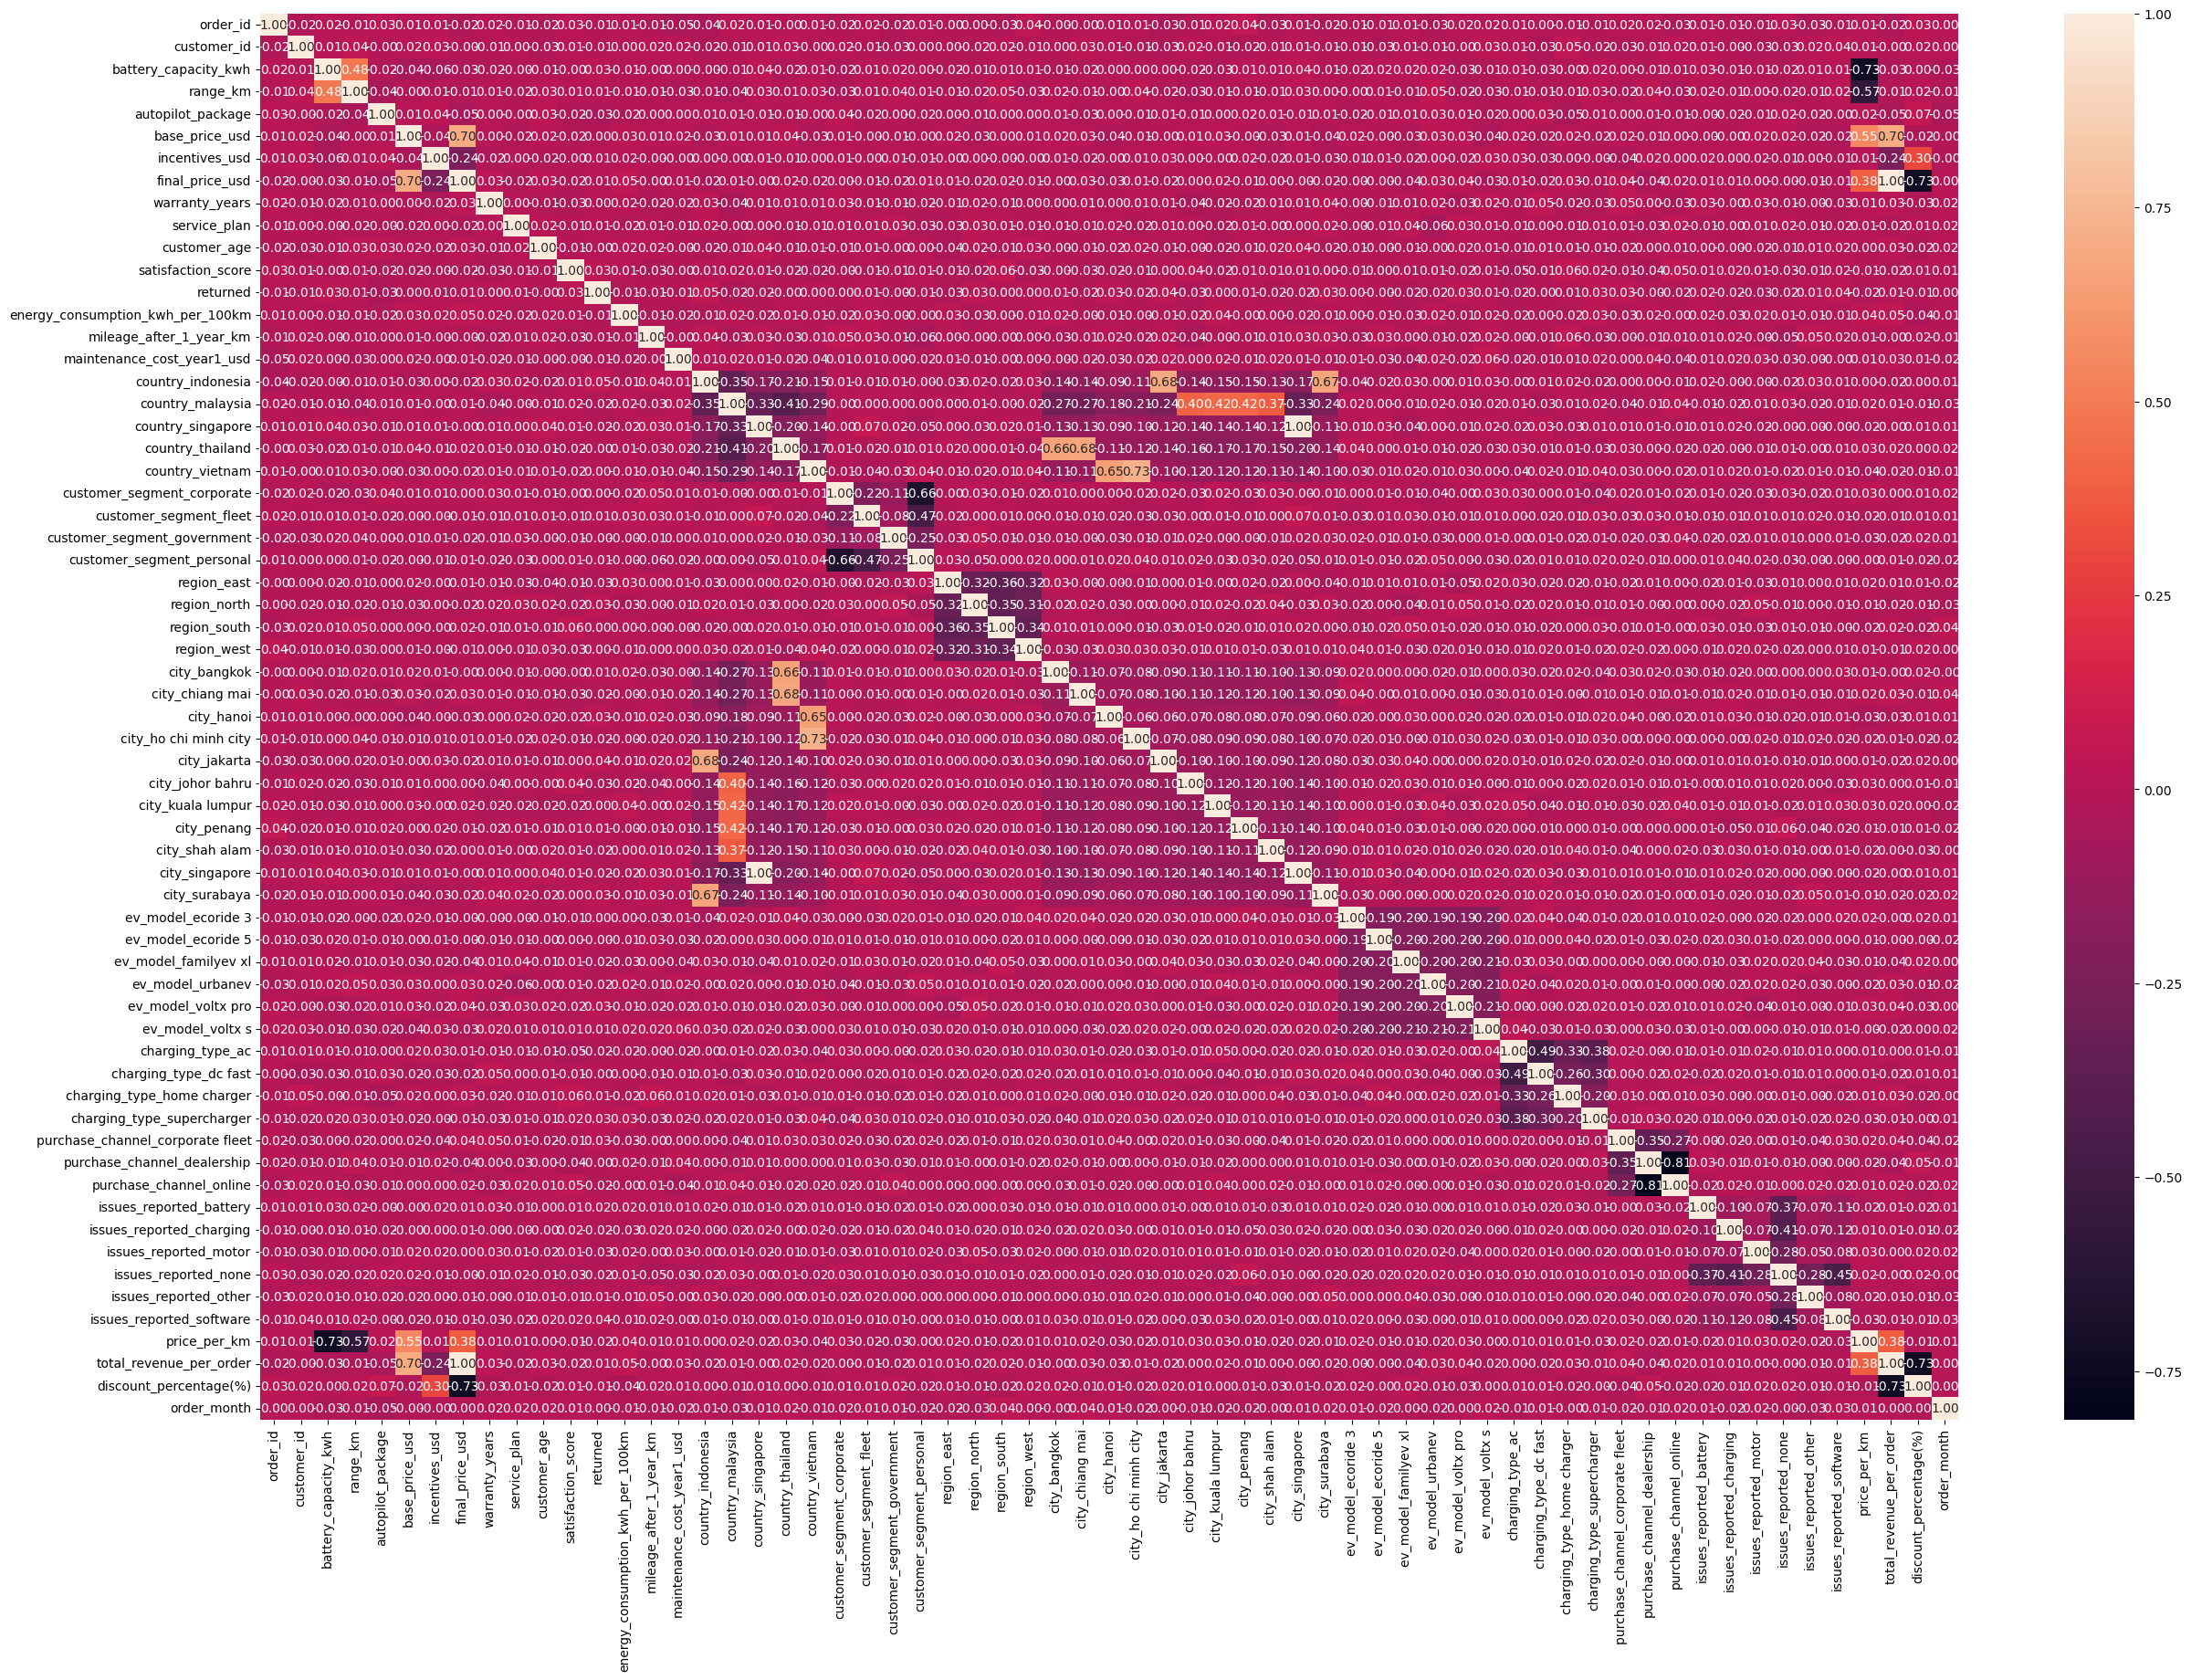

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(30, 20))

sns.heatmap(df_numneric.corr(), annot= True, fmt='.2f')

*Find the corralation matrix in a range (positive)*

In [ ]:
correlation_matrix = df_numneric.corr()

all_correlations = correlation_matrix.unstack()

filtered_correlations = all_correlations[(all_correlations < 0.8) & (all_correlations > 0.4)]

print( filtered_correlations)

battery_capacity_kwh     range_km                   0.484750
range_km                 battery_capacity_kwh       0.484750
base_price_usd           final_price_usd            0.696235
                         price_per_km               0.550547
                         total_revenue_per_order    0.696396
final_price_usd          base_price_usd             0.696235
country_indonesia        city_jakarta               0.684029
                         city_surabaya              0.670557
country_malaysia         city_johor bahru           0.404979
                         city_kuala lumpur          0.422627
                         city_penang                0.423498
country_thailand         city_bangkok               0.660319
                         city_chiang mai            0.675543
country_vietnam          city_hanoi                 0.646521
                         city_ho chi minh city      0.725439
city_bangkok             country_thailand           0.660319
city_chiang mai         

*Find the corralation in a range (Negative)*





In [ ]:

filtered_correlations = all_correlations[(all_correlations < -0.4) & (all_correlations > -0.8)]

print( filtered_correlations)

battery_capacity_kwh        price_per_km                 -0.731766
range_km                    price_per_km                 -0.574141
final_price_usd             discount_percentage(%)       -0.728282
country_malaysia            country_thailand             -0.406124
country_thailand            country_malaysia             -0.406124
customer_segment_corporate  customer_segment_personal    -0.663783
customer_segment_fleet      customer_segment_personal    -0.472747
customer_segment_personal   customer_segment_corporate   -0.663783
                            customer_segment_fleet       -0.472747
charging_type_ac            charging_type_dc fast        -0.493902
charging_type_dc fast       charging_type_ac             -0.493902
issues_reported_charging    issues_reported_none         -0.413730
issues_reported_none        issues_reported_charging     -0.413730
                            issues_reported_software     -0.454827
issues_reported_software    issues_reported_none         -0.45